In [1]:
import sys
import os

# Adds the parent directory (root) to the Python path
sys.path.append(os.path.abspath(os.path.join('..')))


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('../data/raw/cleaned_transactions.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,Sale
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,Sale
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,Sale
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,Sale


In [5]:
df = df[df["Quantity"] >0]
df.shape

(504731, 9)

In [6]:
df['transaction_type'].value_counts()

transaction_type
Sale    504731
Name: count, dtype: int64

Good. I have comfirmed we have only sales data

In [7]:
df['Country'].value_counts()

Country
United Kingdom          466603
EIRE                      9450
Germany                   7645
France                    5514
Netherlands               2728
Spain                     1228
Switzerland               1170
Portugal                  1058
Belgium                   1036
Sweden                     886
Channel Islands            821
Italy                      708
Australia                  630
Cyprus                     533
Austria                    524
Greece                     512
Denmark                    418
United Arab Emirates       399
Norway                     365
Finland                    347
Unspecified                306
USA                        230
Poland                     182
Malta                      170
Japan                      164
Lithuania                  154
Singapore                  117
RSA                        110
Bahrain                    106
Canada                      77
Thailand                    76
Hong Kong                   74


We have so many countries but most sales come from UK

In [8]:
df['Customer ID'].nunique()

4312

## Visualize Unit Price vs Quantity Sold

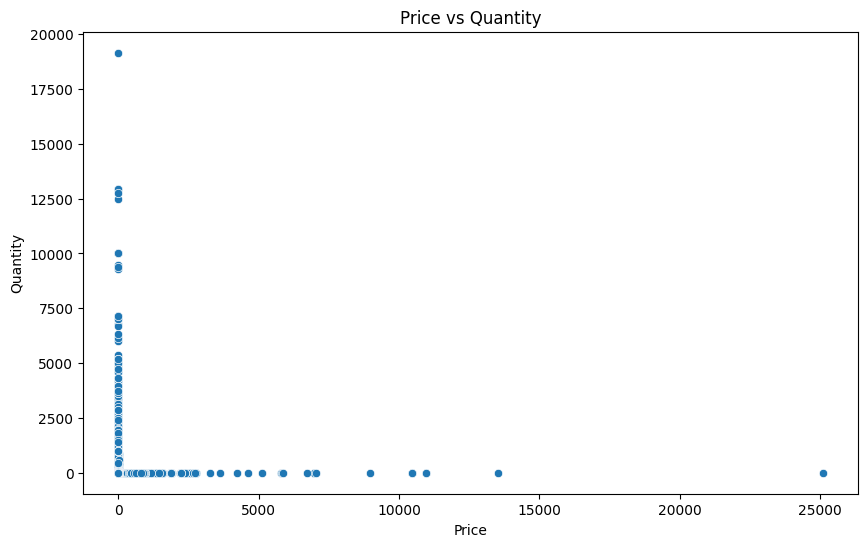

In [9]:
#plot scatter plot of price vs quantity 
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.month
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Price', y='Quantity')
plt.title('Price vs Quantity')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.show()

Text(0, 0.5, 'Quantity (Log Scale)')

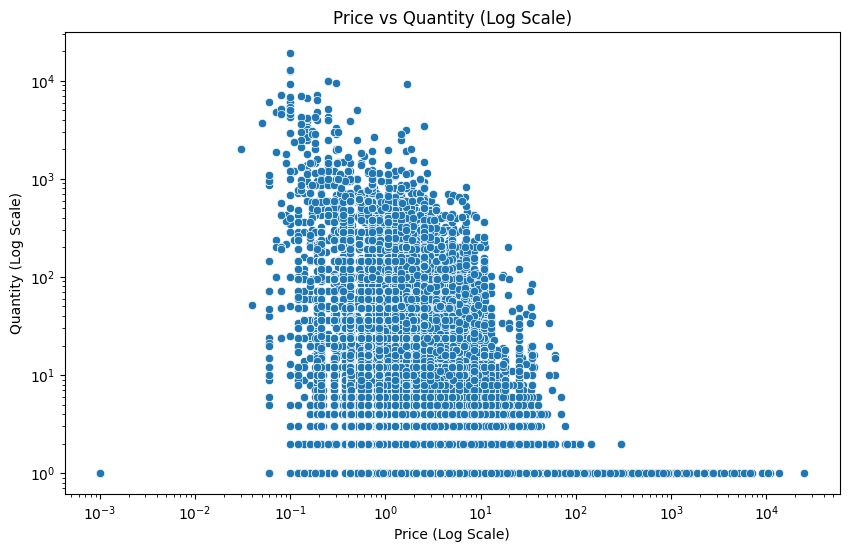

In [10]:
# use log scale for price and quantity
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Price', y='Quantity')
plt.xscale('log')
plt.yscale('log')
plt.title('Price vs Quantity (Log Scale)')
plt.xlabel('Price (Log Scale)')
plt.ylabel('Quantity (Log Scale)')

## Remove Outliers

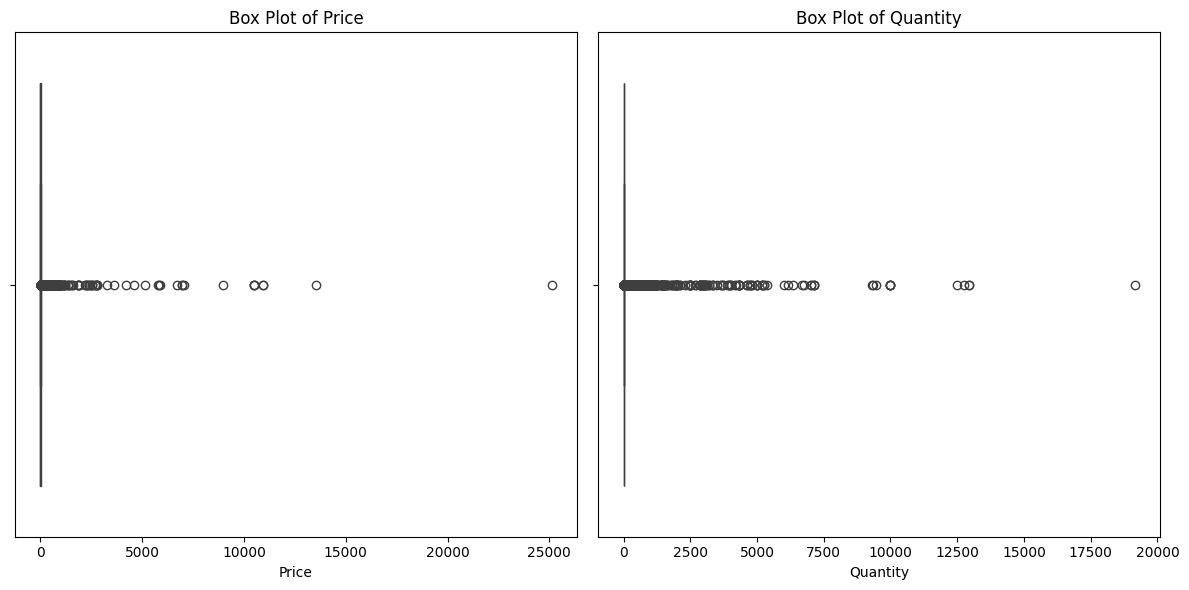

In [11]:
# plot box plots of price and quantity to identify outliers
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='Price')
plt.title('Box Plot of Price')
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Quantity')
plt.title('Box Plot of Quantity')
plt.tight_layout()
plt.show()

In [12]:
df[['Price', 'Quantity']].describe(percentiles=[0.5,0.9,0.95,0.99])

,Price,Quantity
count,504731.000000,504731.000000
mean,4.274692,11.516923
std,64.093333,87.337497
min,0.001000,1.000000
50%,2.100000,3.000000
90%,7.950000,24.000000
95%,10.170000,32.000000
99%,19.950000,120.000000
max,25111.090000,19152.000000


In [13]:
df.nlargest(10, 'Quantity')
df.nlargest(10, 'Price')

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,transaction_type,Month
236539,512771,M,Manual,1,2010-06-17 16:53:00,25111.09,NaN,United Kingdom,Sale,6
507160,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,NaN,United Kingdom,Sale,12
132118,502263,M,Manual,1,2010-03-23 15:22:00,10953.50,12918.0,United Kingdom,Sale,3
132120,502265,M,Manual,1,2010-03-23 15:28:00,10953.50,NaN,United Kingdom,Sale,3
335067,522796,M,Manual,1,2010-09-16 15:12:00,10468.80,NaN,United Kingdom,Sale,9
351302,524159,M,Manual,1,2010-09-27 16:12:00,10468.80,14063.0,United Kingdom,Sale,9
365243,525399,M,Manual,1,2010-10-05 11:49:00,10468.80,NaN,United Kingdom,Sale,10
73045,496115,M,Manual,1,2010-01-29 11:04:00,8985.60,17949.0,United Kingdom,Sale,1
366628,525473,M,Manual,1,2010-10-05 15:16:00,7044.79,NaN,United Kingdom,Sale,10
127147,501766,M,Manual,1,2010-03-19 11:35:00,6958.17,15760.0,Norway,Sale,3


The data is heavily skewed with extreme outliers.

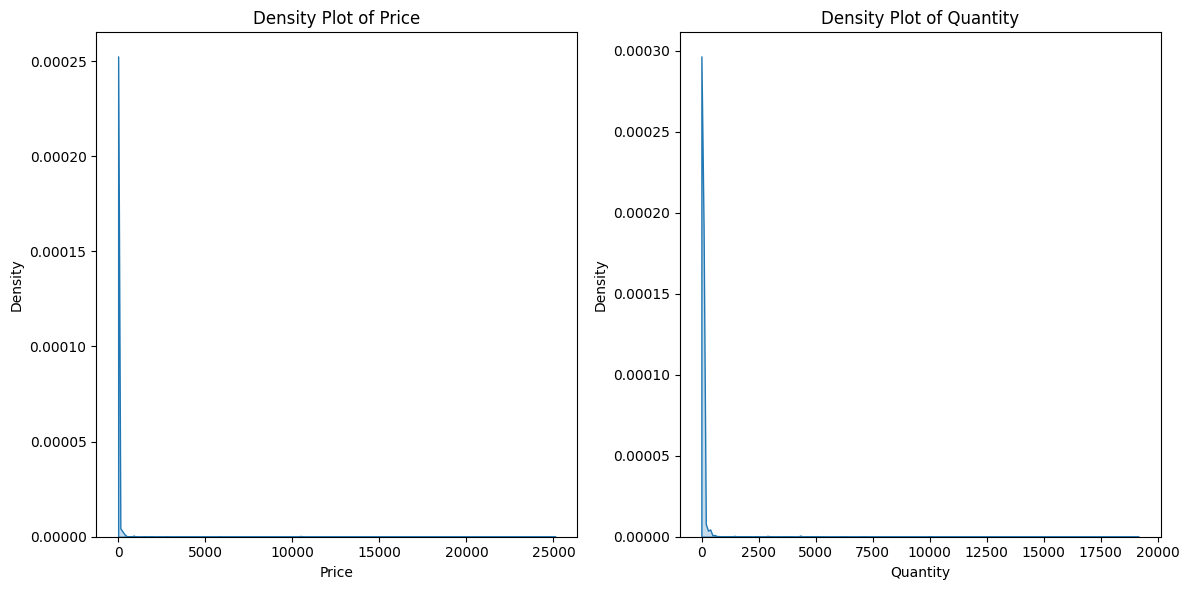

In [14]:
# plot density plot of price and quantity
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.kdeplot(data=df, x='Price', fill=True)
plt.title('Density Plot of Price')
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='Quantity', fill=True)
plt.title('Density Plot of Quantity')
plt.tight_layout()
plt.show()

## Remove Outliers

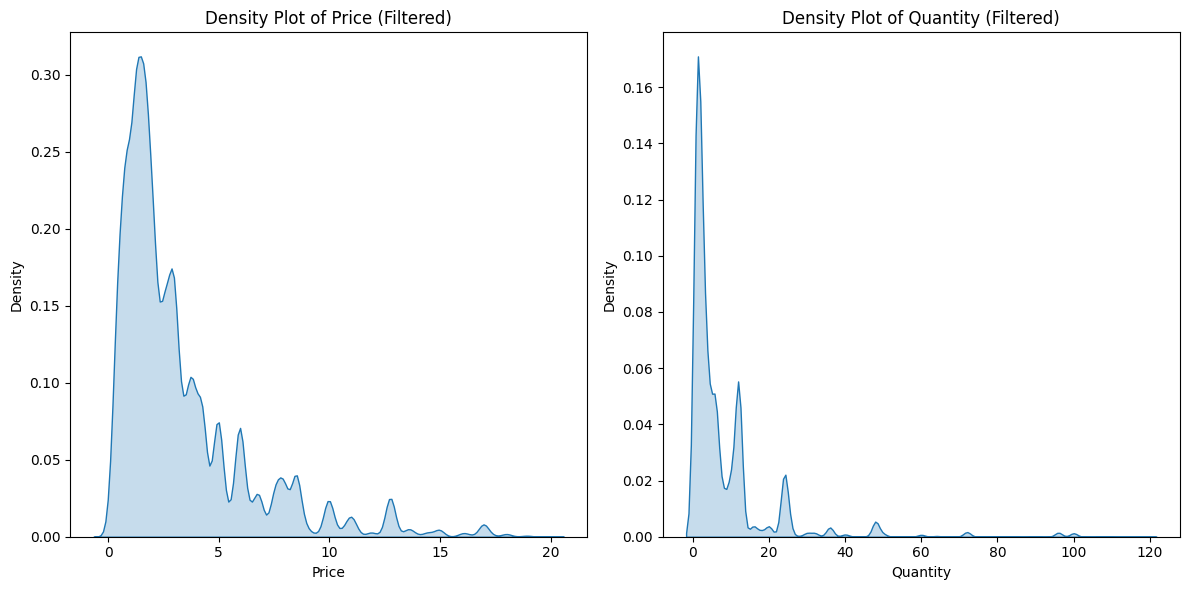

In [15]:
# filter for 99 percentile of price and quantity to remove outliers
q_price = df['Price'].quantile(0.99)
q_qty = df['Quantity'].quantile(0.99)

filtered = df[
    (df['Price'] < q_price) &
    (df['Quantity'] < q_qty)
]

# plot density plot of price and quantity after removing outliers
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
sns.kdeplot(data=filtered, x='Price', fill=True)
plt.title('Density Plot of Price (Filtered)')
plt.subplot(1, 2, 2)
sns.kdeplot(data=filtered, x='Quantity', fill=True)
plt.title('Density Plot of Quantity (Filtered)')
plt.tight_layout()
plt.show()  

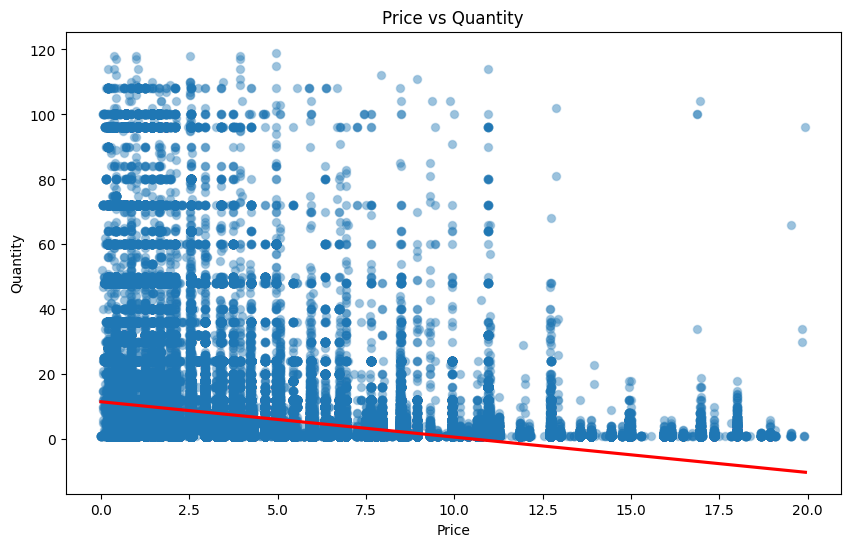

In [16]:
# redo scatter plot of price vs quantity after removing outliers
plt.figure(figsize=(10,6))
sns.scatterplot(data=filtered, x='Price', y='Quantity', alpha=0.3)

# add regression trend line to scatter plot
sns.regplot(data=filtered, x='Price', y='Quantity', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Price vs Quantity')
plt.xlabel('Price')
plt.ylabel('Quantity')
plt.show()


In [17]:
# calculate correlation between price and quantity
correlation = filtered['Price'].corr(filtered['Quantity'])
print(f'Correlation between Price and Quantity: {correlation:.2f}')

Correlation between Price and Quantity: -0.26


In [18]:
filtered[['Price', 'Quantity']].corr()

,Price,Quantity
Price,1.000000,-0.260816
Quantity,-0.260816,1.000000


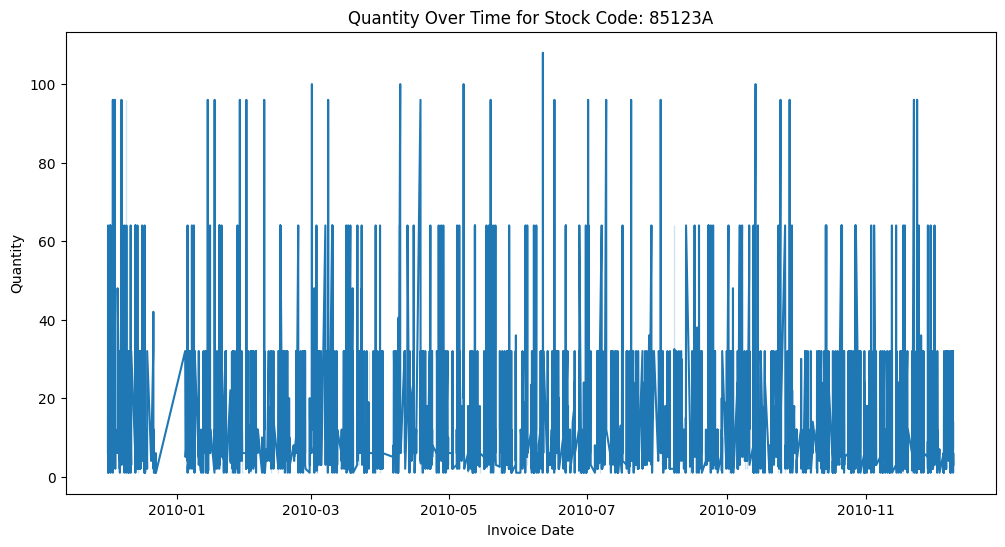

In [19]:
# plot line plot of quantity for a single stock code over time
stock_code = filtered['StockCode'].value_counts().idxmax()

filtered_stock = filtered[filtered['StockCode'] == stock_code]
plt.figure(figsize=(12,6))
sns.lineplot(data=filtered_stock, x='InvoiceDate', y='Quantity')
plt.title(f'Quantity Over Time for Stock Code: {stock_code}')
plt.xlabel('Invoice Date')
plt.ylabel('Quantity')
plt.show()

The data is still right skewed

#### Are these observations real?

In [20]:
df.nlargest(20, 'Quantity')[
    ['InvoiceDate', 'StockCode', 'Quantity', 'Price']
]

,InvoiceDate,StockCode,Quantity,Price
88942,2010-02-15 11:57:00,37410,19152,0.10
124448,2010-03-17 13:09:00,21099,12960,0.10
124450,2010-03-17 13:09:00,21091,12960,0.10
124451,2010-03-17 13:09:00,21085,12744,0.10
124449,2010-03-17 13:09:00,21092,12480,0.10
132132,2010-03-23 15:36:00,21984,10000,0.25
132133,2010-03-23 15:36:00,21982,10000,0.25
132134,2010-03-23 15:36:00,21980,10000,0.25
132135,2010-03-23 15:36:00,21981,10000,0.25
91693,2010-02-17 10:51:00,85220,9456,0.30


### Aggregate Daily Quantity

In [21]:
# aggregate filtered 99th percentile transactions as daily quantity by stock code
filtered['InvoiceDate_day'] = pd.to_datetime(filtered['InvoiceDate']).dt.day
daily_quantity = filtered.groupby(['InvoiceDate_day', 'StockCode'])['Quantity'].sum().reset_index()
daily_quantity.head()   


,InvoiceDate_day,StockCode,Quantity
0,1,10002,182
1,1,10120,90
2,1,10123C,5
3,1,10123G,2
4,1,10125,7


In [22]:
daily_quantity['Quantity'].describe(
    percentiles=[.95,.99,.995]
)

count    84073.000000
mean        47.138998
std         88.286902
min          1.000000
95%        196.000000
99%        414.000000
99.5%      531.640000
max       2104.000000
Name: Quantity, dtype: float64

In [23]:
# aggregate original transactions as daily quantity by stock code and day of month
df['InvoiceDate_day'] = df['InvoiceDate'].dt.day
daily_quantity = (
    df.groupby(
        ['InvoiceDate_day', 'StockCode']
    )['Quantity']
    .sum()
    .reset_index()
)

# inspect
daily_quantity['Quantity'].describe(
    percentiles=[.95,.99,.995]
)


count    85305.00000
mean        68.14311
std        250.93023
min          1.00000
95%        271.00000
99%        730.00000
99.5%     1105.96000
max      19164.00000
Name: Quantity, dtype: float64

### Is the Max 19K Quantity A Random Isolation?

In [24]:
# sort daily quantity by quantity to identify top transactions
daily_quantity.nlargest(20, 'Quantity')

,InvoiceDate_day,StockCode,Quantity
41927,15,37410,19164
46113,17,21099,12961
46106,17,21091,12960
46100,17,21085,12748
46107,17,21092,12492
5959,3,17003,11176
63292,23,21984,11156
63290,23,21982,11019
63289,23,21981,10320
63288,23,21980,10202


In [25]:
# print how many transactions have quantity greater than 1000
num_large_transactions = daily_quantity[daily_quantity['Quantity'] > 1000]
print(f'Number of transactions with quantity greater than 1k: {num_large_transactions.shape[0]}') 
print("\n")
display(num_large_transactions.sort_values(by='Quantity', ascending=False))

Number of transactions with quantity greater than 1k: 500




,InvoiceDate_day,StockCode,Quantity
41927,15,37410,19164
46113,17,21099,12961
46106,17,21091,12960
46100,17,21085,12748
46107,17,21092,12492
...,...,...,...
1016,1,21977,1010
25938,9,85230F,1008
35707,13,22355,1003
24074,9,21790,1002


A very tiny fraction; only 500 out of over 504,731K transactions have quantities over 1K, 
approximately **0.1% of the total transactions**; 500/504731 

### Are These 500 Transactions Contributing a Huge Share of Volume?

In [26]:
high_qty = df[df['Quantity'] > 1000]

(high_qty['Quantity'].sum() / df['Quantity'].sum())* 100

np.float64(10.677542616930342)

- 500 transactions (0.1% of transactions) account for 10.7% of total volume.

- This is not a simple long tail but a fundamentally different demand regime.

**Next Question is whether to model retail demand, wholesale demand, or both?**

- Why this matters

| Type | Typical Quantity|
|---:|---:|
| Retail order | 1–20 |
| Small bulk order | 50–200|
|Wholesale order | 1000–19000|

- If a forecasting model sees all three together, it will try to learn a single process for multiple demand-generating mechanisms.
That often hurts forecasting.

In [30]:
sku_grouped = daily_quantity.groupby('StockCode')['Quantity'].median().sort_values(ascending=False)
sku_grouped = sku_grouped.reset_index()
sku_grouped.head(20)

,StockCode,Quantity
0,21212,1846.0
1,85123A,1759.0
2,85099B,1573.0
3,85220,1378.0
4,84077,1302.0
5,84879,1262.0
6,84991,1061.0
7,21977,1010.0
8,85218,996.0
9,17003,817.5


In [31]:
sku_grouped.tail(20)

,StockCode,Quantity
4231,22868,1.0
4232,16245A,1.0
4233,85043,1.0
4234,22886,1.0
4235,22885,1.0
4236,22879,1.0
4237,22878,1.0
4238,22872,1.0
4239,22870,1.0
4240,85077,1.0


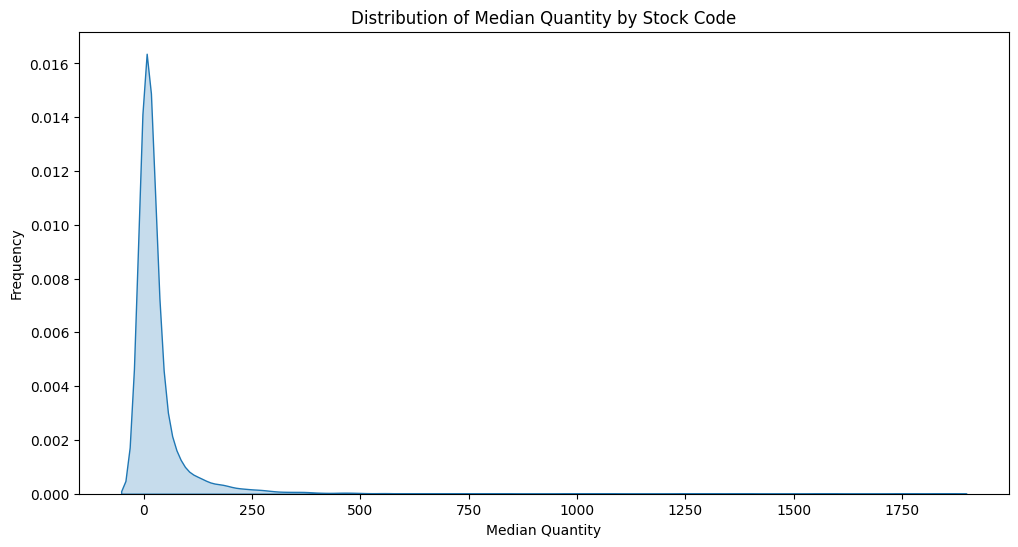

In [33]:
# plot distribution of median quantity by stock code kde plot
plt.figure(figsize=(12,6))
sns.kdeplot(data=sku_grouped, x="Quantity", fill=True)
plt.title('Distribution of Median Quantity by Stock Code')
plt.xlabel('Median Quantity')
plt.ylabel('Frequency')
plt.show()

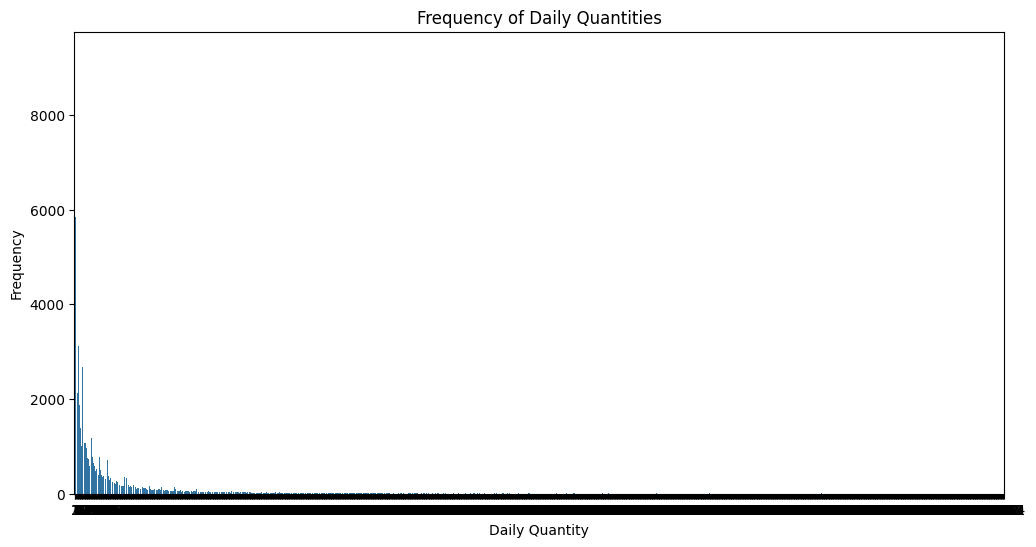

In [34]:
qty_count = daily_quantity['Quantity'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=qty_count.index, y=qty_count.values)
plt.title('Frequency of Daily Quantities')
plt.xlabel('Daily Quantity')
plt.ylabel('Frequency')
plt.show()

In [35]:
bins = [
    0,
    20,
    100,
    300,
    1000,
    np.inf
]

In [36]:
daily_quantity.groupby(
    pd.cut(daily_quantity['Quantity'], bins)
)['Quantity'].agg(['count','sum'])

,count,sum
Quantity,,
"(0.0, 20.0]",46056,307805
"(20.0, 100.0]",26399,1254319
"(100.0, 300.0]",9178,1569755
"(300.0, 1000.0]",3172,1552589
"(1000.0, inf]",500,1128480
